# Day 1 — Can a Neural Network Predict a Stock?

This notebook completes the Week 2 Day 1 task using **ABUK**.

We use today's market features to predict **the next trading day's return** with a multilayer perceptron (MLP). The split is chronological: the oldest 70% is training data and the newest 30% is unseen test data.

Required outputs:

- training loss vs. testing loss;
- predicted returns vs. actual returns for training and testing periods;
- experiments with epochs, layers, and hidden neurons;
- an evidence-based answer to: **Does a bigger network mean a better predictor?**

> This is an educational prediction experiment, not financial advice.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Works both from inside the repo and from this generated deliverable folder.
candidates = [Path.cwd(), *Path.cwd().parents, Path('/Users/adhamelbaz/2026-orion')]
REPO_ROOT = next(
    (p for p in candidates if (p / 'src').exists() and (p / 'data' / 'egx').exists()),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError('Could not find the 2026-orion repo. Set REPO_ROOT manually.')

sys.path.insert(0, str(REPO_ROOT / 'src'))

from tradinglab.data_feed import DataFeed
from tradinglab.features import FEATURE_NAMES, feature_columns

SYMBOL = 'ABUK'
DATA_DIR = REPO_ROOT / 'data' / 'egx'
print(f'Repo: {REPO_ROOT}')
print(f'Stock: {SYMBOL}')

Repo: /Users/adhamelbaz/2026-orion
Stock: ABUK


## 1. Build the prediction dataset

The five inputs are already defined centrally by the project:

1. today's return;
2. price relative to the 10-day moving average;
3. price relative to the 30-day moving average;
4. 14-day RSI;
5. 20-day rolling volatility.

For a row dated day (t), the label is the close-to-close return on day (t+1). Rows with missing warm-up values are removed.

In [2]:
feed = DataFeed.from_dir(DATA_DIR, symbols=[SYMBOL])
X_full = feature_columns(feed, asset=0)

y_full = np.full(feed.n_days, np.nan)
y_full[:-1] = feed.returns[1:, 0]  # next-day return

valid = ~np.isnan(X_full).any(axis=1) & ~np.isnan(y_full)
valid_days = np.flatnonzero(valid)

X = X_full[valid].astype(np.float32)
y = y_full[valid].astype(np.float32)
target_dates = feed.dates[valid_days + 1]

dataset = pd.DataFrame(X, columns=FEATURE_NAMES, index=target_dates)
dataset['next_day_return'] = y

print(f'Usable observations: {len(dataset):,}')
print(f'Prediction dates: {dataset.index.min().date()} to {dataset.index.max().date()}')
display(dataset.head())

Usable observations: 2,827
Prediction dates: 2015-02-17 to 2026-07-30


,return,p/sma_fast,p/sma_slow,rsi,volatility,next_day_return
date,,,,,,
2015-02-17,0.019445,0.017709,0.010723,0.677419,0.018530,-0.030185
2015-02-18,-0.030185,-0.011215,-0.019197,0.403325,0.019752,0.018395
2015-02-19,0.018395,0.006973,-0.000756,0.493465,0.019369,-0.051625
2015-02-22,-0.051625,-0.040021,-0.050313,0.344651,0.022350,0.000000
2015-02-23,0.000000,-0.034978,-0.048276,0.347826,0.021921,0.000000


## 2. Chronological 70/30 split

We do **not** shuffle. Training uses the past and testing uses the future. Feature means and standard deviations are learned from training data only, then reused on the test data.

In [3]:
cut = int(len(X) * 0.70)
X_train, X_test = X[:cut], X[cut:]
y_train, y_test = y[:cut], y[cut:]
dates_train, dates_test = target_dates[:cut], target_dates[cut:]

feature_mean = X_train.mean(axis=0)
feature_std = X_train.std(axis=0)
feature_std[feature_std == 0] = 1.0

X_train_scaled = ((X_train - feature_mean) / feature_std).astype(np.float32)
X_test_scaled = ((X_test - feature_mean) / feature_std).astype(np.float32)

print(f'Train: {len(X_train):,} rows ({dates_train.min().date()} → {dates_train.max().date()})')
print(f'Test:  {len(X_test):,} rows ({dates_test.min().date()} → {dates_test.max().date()})')

Train: 1,978 rows (2015-02-17 → 2023-01-23)
Test:  849 rows (2023-01-24 → 2026-07-30)


## 3. Define and train MLPs

An MLP passes the five inputs through fully connected hidden layers. ReLU introduces non-linearity, and the final neuron outputs one number: predicted next-day return.

We compare three capacities under the same training setup:

- **Small:** one hidden layer with 8 neurons;
- **Baseline:** one hidden layer with 32 neurons;
- **Large/deep:** three hidden layers with 64, 32, and 16 neurons.

In [4]:
class ReturnMLP(nn.Module):
    def __init__(self, n_features, hidden_layers):
        super().__init__()
        layers = []
        in_size = n_features
        for hidden_size in hidden_layers:
            layers.extend([nn.Linear(in_size, hidden_size), nn.ReLU()])
            in_size = hidden_size
        layers.append(nn.Linear(in_size, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x).squeeze(-1)


def fit_model(hidden_layers, epochs=300, learning_rate=1e-3, seed=SEED):
    torch.manual_seed(seed)
    model = ReturnMLP(X_train_scaled.shape[1], hidden_layers)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    Xtr = torch.tensor(X_train_scaled)
    ytr = torch.tensor(y_train)
    Xte = torch.tensor(X_test_scaled)
    yte = torch.tensor(y_test)
    history = {'train': [], 'test': []}

    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        train_loss = loss_fn(model(Xtr), ytr)
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            test_loss = loss_fn(model(Xte), yte)
        history['train'].append(train_loss.item())
        history['test'].append(test_loss.item())

    return model, history


def predict(model, X_scaled):
    model.eval()
    with torch.no_grad():
        return model(torch.tensor(X_scaled)).numpy()


def metrics(actual, predicted):
    mse = np.mean((actual - predicted) ** 2)
    mae = np.mean(np.abs(actual - predicted))
    direction = np.mean(np.sign(actual) == np.sign(predicted))
    correlation = np.corrcoef(actual, predicted)[0, 1]
    return {'MSE': mse, 'MAE': mae, 'Direction accuracy': direction, 'Correlation': correlation}

In [5]:
experiments = {
    'Small [8]': [8],
    'Baseline [32]': [32],
    'Large [64, 32, 16]': [64, 32, 16],
}

trained = {}
rows = []
for name, architecture in experiments.items():
    model, history = fit_model(architecture, epochs=300)
    pred_train = predict(model, X_train_scaled)
    pred_test = predict(model, X_test_scaled)
    trained[name] = (model, history, pred_train, pred_test)
    train_metrics = metrics(y_train, pred_train)
    test_metrics = metrics(y_test, pred_test)
    rows.append({
        'Model': name,
        'Parameters': sum(p.numel() for p in model.parameters()),
        'Train MSE': train_metrics['MSE'],
        'Test MSE': test_metrics['MSE'],
        'Test MAE': test_metrics['MAE'],
        'Test direction accuracy': test_metrics['Direction accuracy'],
        'Test correlation': test_metrics['Correlation'],
    })

results = pd.DataFrame(rows).set_index('Model').sort_values('Test MSE')

# A zero-return forecast is a useful reality check for noisy daily returns.
zero_baseline_mse = np.mean(y_test ** 2)
results['Beats zero-return baseline'] = results['Test MSE'] < zero_baseline_mse

display(results.style.format({
    'Train MSE': '{:.8f}',
    'Test MSE': '{:.8f}',
    'Test MAE': '{:.4%}',
    'Test direction accuracy': '{:.2%}',
    'Test correlation': '{:.3f}',
}))
print(f'Zero-return baseline test MSE: {zero_baseline_mse:.8f}')

,Parameters,Train MSE,Test MSE,Test MAE,Test direction accuracy,Test correlation,Beats zero-return baseline
Model,,,,,,,
"Large [64, 32, 16]",3009,0.00042360,0.00084864,1.9158%,47.59%,-0.002,False
Baseline [32],225,0.00096725,0.00136337,2.6188%,48.53%,0.039,False
Small [8],57,0.00097982,0.00158376,2.8550%,45.70%,0.032,False


Zero-return baseline test MSE: 0.00068540


### Epoch experiment

Epochs control how many times the optimizer updates the model using the training set. Too few can underfit; too many can overfit. Here the same 32-neuron network is trained for different durations.

,Train MSE,Test MSE
Epochs,,
50,0.00867529,0.01203723
150,0.00173916,0.00246418
300,0.00096725,0.00136337
600,0.00065253,0.00094438


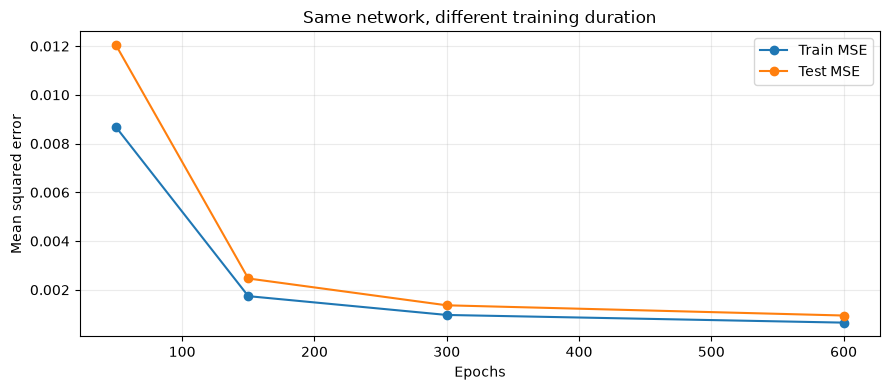

In [6]:
epoch_rows = []
for epoch_count in [50, 150, 300, 600]:
    epoch_model, epoch_history = fit_model([32], epochs=epoch_count)
    epoch_train_pred = predict(epoch_model, X_train_scaled)
    epoch_test_pred = predict(epoch_model, X_test_scaled)
    epoch_rows.append({
        'Epochs': epoch_count,
        'Train MSE': np.mean((y_train - epoch_train_pred) ** 2),
        'Test MSE': np.mean((y_test - epoch_test_pred) ** 2),
    })

epoch_results = pd.DataFrame(epoch_rows).set_index('Epochs')
display(epoch_results.style.format('{:.8f}'))

ax = epoch_results.plot(marker='o', figsize=(9, 4), title='Same network, different training duration')
ax.set_ylabel('Mean squared error')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## 4. Required loss plot

- **Training loss** measures fit on historical examples seen by the model.
- **Testing loss** measures generalization to later, unseen history.
- If training loss keeps falling while testing loss rises, the model is overfitting.

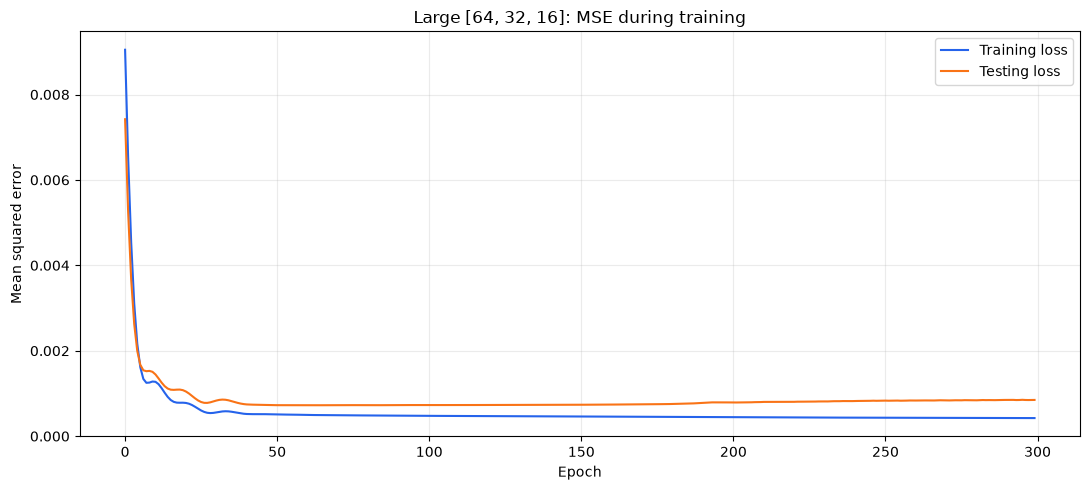

In [7]:
best_name = results.index[0]
best_model, best_history, pred_train, pred_test = trained[best_name]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(best_history['train'], label='Training loss', color='#2563eb')
ax.plot(best_history['test'], label='Testing loss', color='#f97316')
ax.set(title=f'{best_name}: MSE during training', xlabel='Epoch', ylabel='Mean squared error')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 5. Required predicted-vs-actual plots

These plots compare the return forecast with what actually happened. A useful model should follow both the timing and direction of the actual return series. Daily returns are noisy, so visual overlap is usually imperfect.

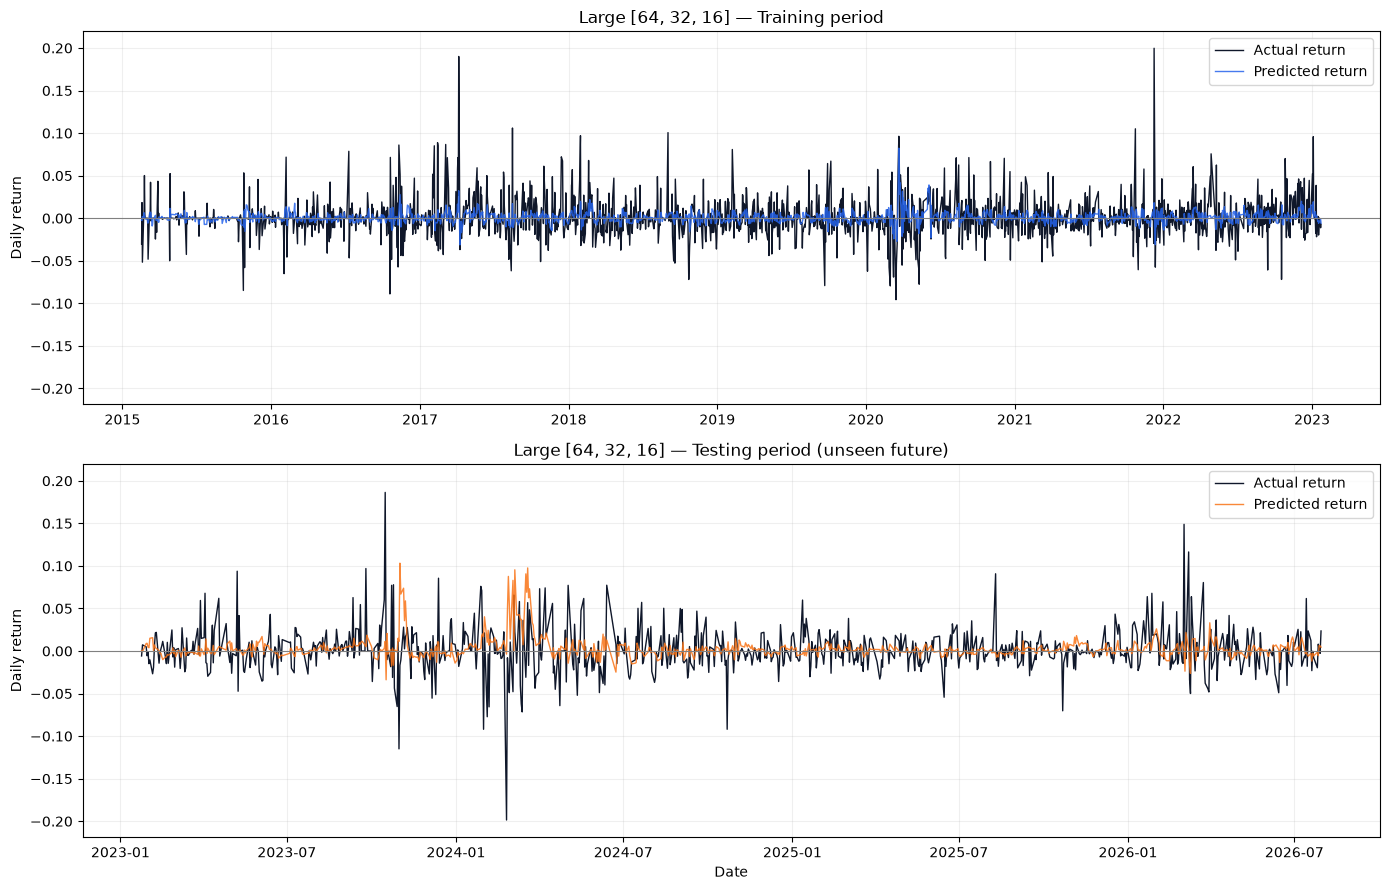

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharey=True)

axes[0].plot(dates_train, y_train, label='Actual return', color='#0f172a', linewidth=1)
axes[0].plot(dates_train, pred_train, label='Predicted return', color='#2563eb', linewidth=1, alpha=0.85)
axes[0].set_title(f'{best_name} — Training period')

axes[1].plot(dates_test, y_test, label='Actual return', color='#0f172a', linewidth=1)
axes[1].plot(dates_test, pred_test, label='Predicted return', color='#f97316', linewidth=1, alpha=0.85)
axes[1].set_title(f'{best_name} — Testing period (unseen future)')

for ax in axes:
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.set_ylabel('Daily return')
    ax.grid(alpha=0.2)
    ax.legend(loc='upper right')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

## 6. Price and model-driven portfolio

The prediction is converted into a deliberately simple trading rule on the **unseen test period**:

- predicted return above zero → invest the full portfolio in ABUK for that day;
- predicted return at or below zero → remain in cash;
- initial cash is **1,000 EGP**;
- transaction costs, slippage, dividends, and fractional-share restrictions are ignored.

Because each forecast is made for its corresponding next trading day, the signal is applied to that day's actual return without looking ahead.

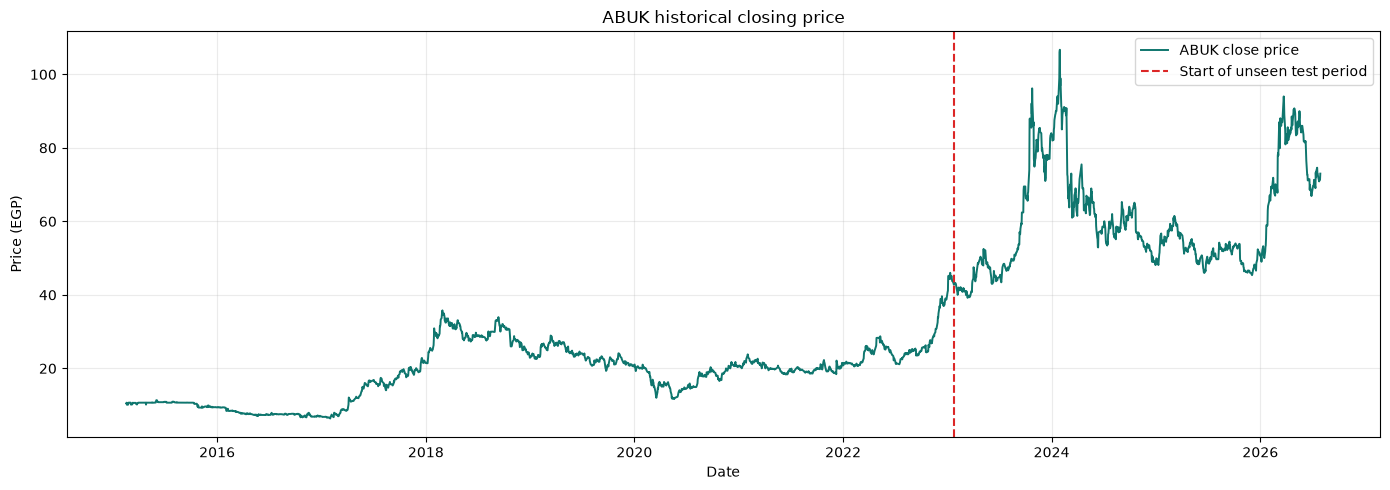

Initial portfolio: 1,000.00 EGP
Final portfolio value: 1,773.31 EGP
Portfolio return: 77.33%


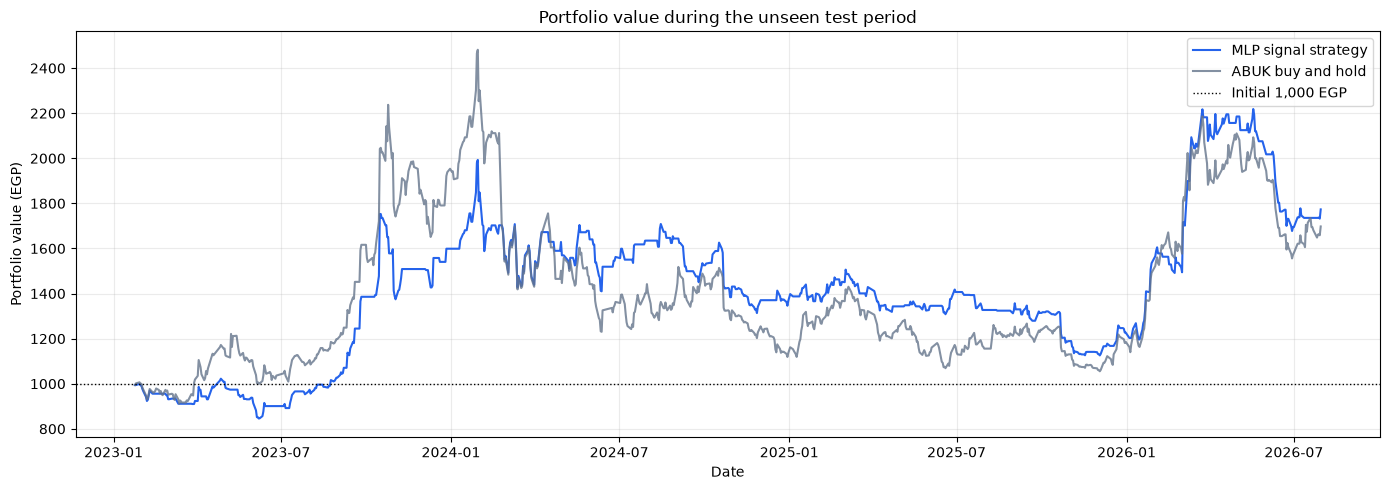

In [9]:
# Closing prices corresponding to the return dates used by the model.
target_prices = feed.close[valid_days + 1, 0]
prices_train, prices_test = target_prices[:cut], target_prices[cut:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(target_dates, target_prices, color='#0f766e', linewidth=1.4, label=f'{SYMBOL} close price')
ax.axvline(dates_test[0], color='#dc2626', linestyle='--', label='Start of unseen test period')
ax.set(title=f'{SYMBOL} historical closing price', xlabel='Date', ylabel='Price (EGP)')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

INITIAL_CASH = 1_000.0
position = (pred_test > 0).astype(float)
strategy_returns = position * y_test
portfolio_values = INITIAL_CASH * np.cumprod(1 + strategy_returns)

# Buy-and-hold comparison beginning on the same test date.
buy_hold_values = INITIAL_CASH * np.cumprod(1 + y_test)

final_portfolio_value = float(portfolio_values[-1])
portfolio_return = final_portfolio_value / INITIAL_CASH - 1

print(f'Initial portfolio: {INITIAL_CASH:,.2f} EGP')
print(f'Final portfolio value: {final_portfolio_value:,.2f} EGP')
print(f'Portfolio return: {portfolio_return:.2%}')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(dates_test, portfolio_values, color='#2563eb', label='MLP signal strategy')
ax.plot(dates_test, buy_hold_values, color='#64748b', alpha=0.8, label='ABUK buy and hold')
ax.axhline(INITIAL_CASH, color='black', linestyle=':', linewidth=1, label='Initial 1,000 EGP')
ax.set(title='Portfolio value during the unseen test period', xlabel='Date', ylabel='Portfolio value (EGP)')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Does bigger mean better?

We answer from unseen test MSE, not training MSE. The cell below generates the conclusion directly from the experiment.

In [10]:
small_test = results.loc['Small [8]', 'Test MSE']
large_test = results.loc['Large [64, 32, 16]', 'Test MSE']
winner = results.index[0]

if large_test < small_test:
    size_answer = 'In this run the large network tested better than the small network, but that alone does not prove that bigger is always better.'
else:
    size_answer = 'No. The larger network tested worse than the small network, even though it had much more capacity.'

winner_beats_baseline = bool(results.loc[winner, 'Beats zero-return baseline'])
baseline_answer = (
    'It also beat the zero-return baseline on test MSE.'
    if winner_beats_baseline
    else 'It did not beat the simple zero-return baseline on test MSE.'
)

print(f'Best unseen test MSE: {winner}')
print(size_answer)
print(baseline_answer)
print('Conclusion: network size is a hyperparameter, not a guarantee. Judge it on later unseen data; lower training error by itself is not evidence of predictability.')

Best unseen test MSE: Large [64, 32, 16]
In this run the large network tested better than the small network, but that alone does not prove that bigger is always better.
It did not beat the simple zero-return baseline on test MSE.
Conclusion: network size is a hyperparameter, not a guarantee. Judge it on later unseen data; lower training error by itself is not evidence of predictability.


## 8. Interpretation checklist

- A lower **test MSE** is better.
- **Direction accuracy** near 50% is coin-flip territory.
- **Correlation** near zero means forecasts do not move consistently with actual returns.
- Beating another neural network is not enough; compare with a simple zero-return forecast.
- This single 70/30 test is the assignment's requested first experiment. Stronger evidence would require walk-forward validation, transaction costs, and testing across multiple stocks.